# Wavelet Transform in Python: Signal Processing & Analysis

This notebook explores **Wavelet Transforms** from the ground up. We will cover:

- Mother wavelets and the wavelet basis
- Continuous Wavelet Transform (CWT) and scalograms
- Discrete Wavelet Transform (DWT): approximation & detail coefficients
- Multi-level decomposition and perfect reconstruction
- Scale-to-frequency relationship
- Wavelet denoising via thresholding
- Time-frequency resolution: Wavelets vs Fourier (STFT)
- Wavelet Packet decomposition

**Requirements:** `numpy`, `matplotlib`, `scipy`, `PyWavelets` (`pip install PyWavelets`)


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
import pywt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10


## 1. What is a Wavelet?

A **wavelet** is a small, oscillating function of finite duration. Unlike sine waves (which extend infinitely), wavelets are localized in time. By scaling (stretching/compressing) and shifting (translating) a single prototype called the **mother wavelet** $\psi(t)$, we can build a basis for analyzing signals at different resolutions.

The mother wavelet must satisfy the **admissibility condition**:

$$\int_{-\infty}^{\infty} \psi(t) \, dt = 0$$

Common families include:
- **Haar**: simplest, piecewise constant
- **Daubechies (db)**: compact support, orthogonal
- **Symlets (sym)**: near-symmetric Daubechies
- **Coiflets (coif)**: vanishing moments for both wavelet and scaling functions
- **Biorthogonal (bior)**: symmetric, used in image compression (JPEG 2000)
- 

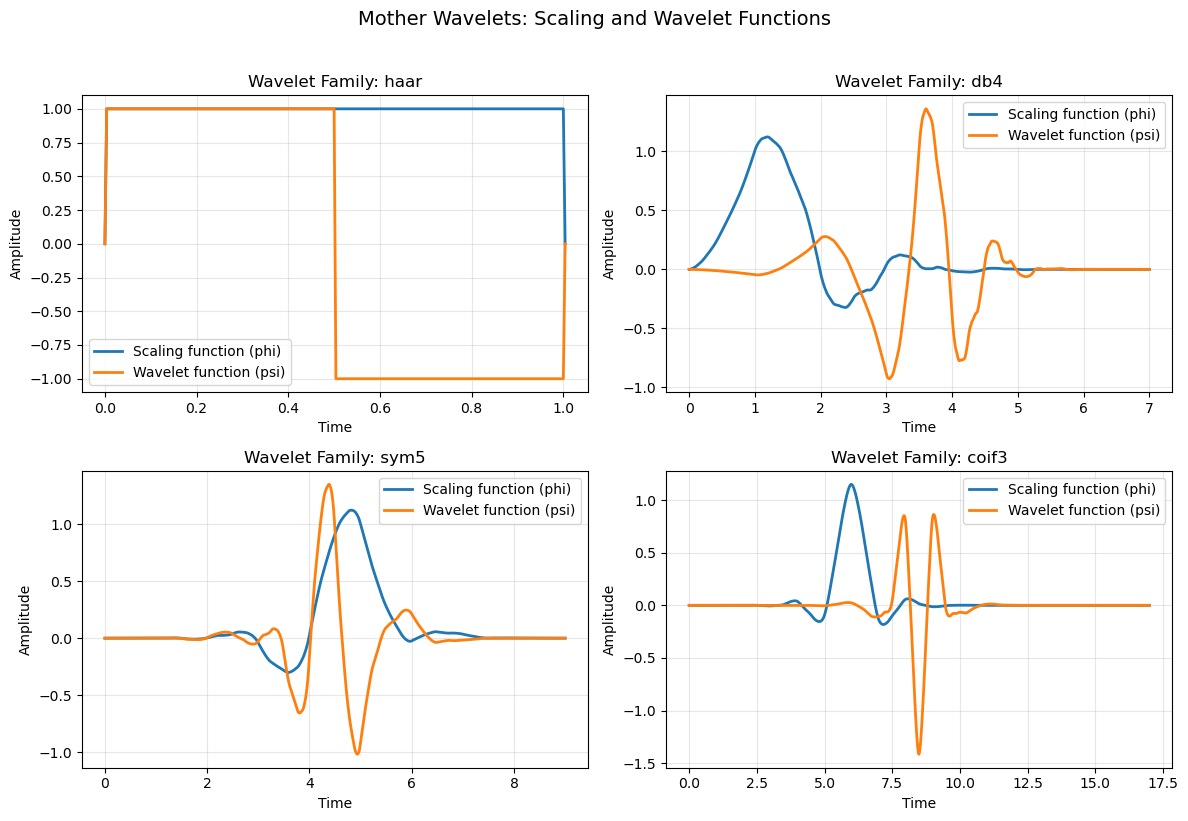

In [8]:
# Visualize mother wavelets (scaling function phi and wavelet function psi)
wavelets = ['haar', 'db4', 'sym5', 'coif3']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, name in enumerate(wavelets):
    wav = pywt.Wavelet(name)
    phi, psi, x = wav.wavefun(level=8)
    
    ax = axes[idx]
    ax.plot(x, phi, linewidth=2, label='Scaling function (phi)')
    ax.plot(x, psi, linewidth=2, label='Wavelet function (psi)')
    ax.set_title(f'Wavelet Family: {name}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Amplitude')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Mother Wavelets: Scaling and Wavelet Functions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 2. Continuous Wavelet Transform (CWT)

The CWT correlates the signal with scaled and shifted versions of the mother wavelet:

$$W(a, b) = \frac{1}{\sqrt{a}} \int_{-\infty}^{\infty} x(t) \, \psi^*\left(\frac{t - b}{a}\right) dt$$

Where:
- $a$ = scale (dilation, inverse of frequency)
- $b$ = shift (translation in time)
- $\psi^*$ = complex conjugate of the mother wavelet

The result is a 2D representation called a **scalogram**, showing how spectral content evolves over time. We use the **Complex Morlet** wavelet for its good balance of time and frequency localization.


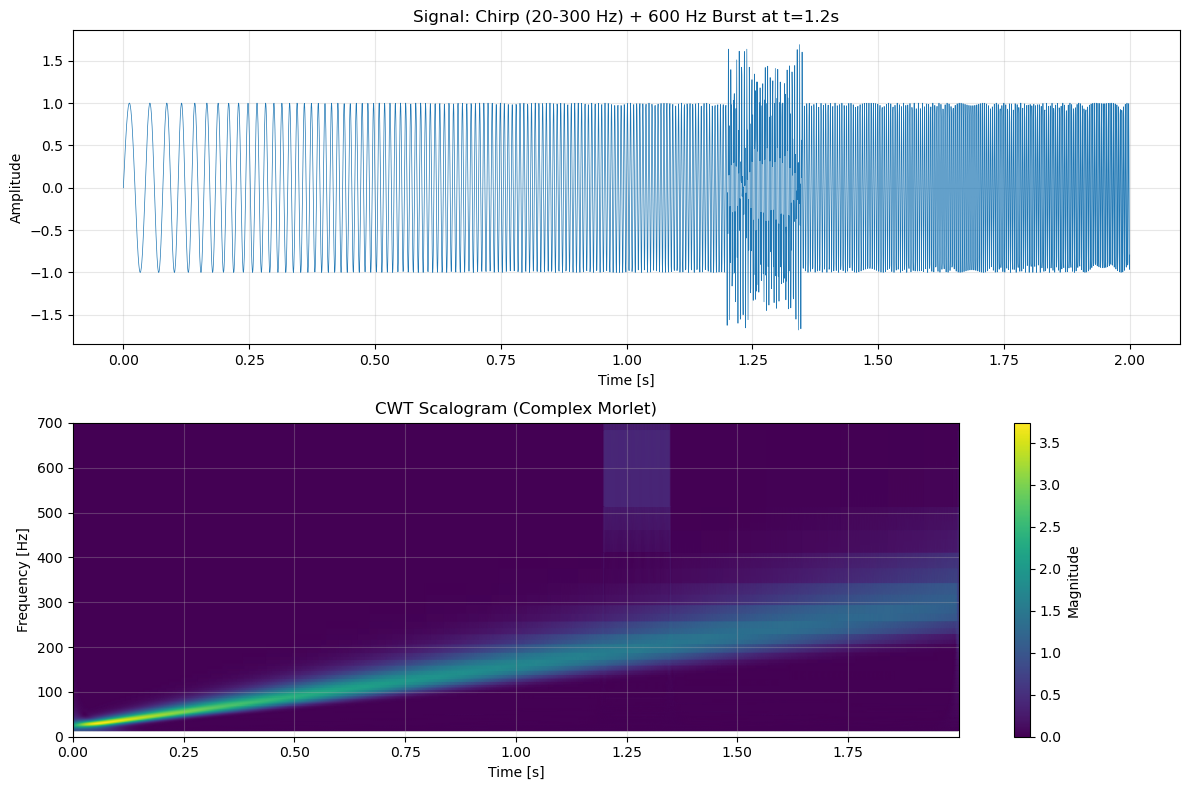

In [9]:
# Create a non-stationary signal: chirp + transient burst
fs = 2048
t = np.linspace(0, 2, 2 * fs, endpoint=False)

# Frequency sweep from 20 Hz to 300 Hz
f0, f1 = 20, 300
chirp = np.sin(2 * np.pi * (f0 * t + (f1 - f0) * t**2 / (2 * 2)))

# Add a short high-frequency burst at t = 1.2s
burst = np.zeros_like(t)
start, end = int(1.2 * fs), int(1.35 * fs)
burst[start:end] = 0.7 * np.sin(2 * np.pi * 600 * t[start:end])
signal_cwt = chirp + burst

# CWT with Complex Morlet wavelet
scales = np.arange(1, 150)
coef, freqs = pywt.cwt(signal_cwt, scales, 'cmor1.5-1.0', sampling_period=1/fs)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(t, signal_cwt, linewidth=0.5)
axes[0].set_title('Signal: Chirp (20-300 Hz) + 600 Hz Burst at t=1.2s')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

im = axes[1].pcolormesh(t, freqs, np.abs(coef), shading='gouraud', cmap='viridis')
axes[1].set_title('CWT Scalogram (Complex Morlet)')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_ylim(0, 700)
fig.colorbar(im, ax=axes[1], label='Magnitude')

plt.tight_layout()
plt.show()


## 3. Discrete Wavelet Transform (DWT)

While the CWT is highly redundant, the **DWT** provides a minimal, non-redundant representation using filter banks. A single DWT level splits the signal into:

- **Approximation coefficients (cA)**: low-frequency content (low-pass filter + downsampling)
- **Detail coefficients (cD)**: high-frequency content (high-pass filter + downsampling)

This is the foundation of the **Mallat algorithm** (pyramid decomposition).


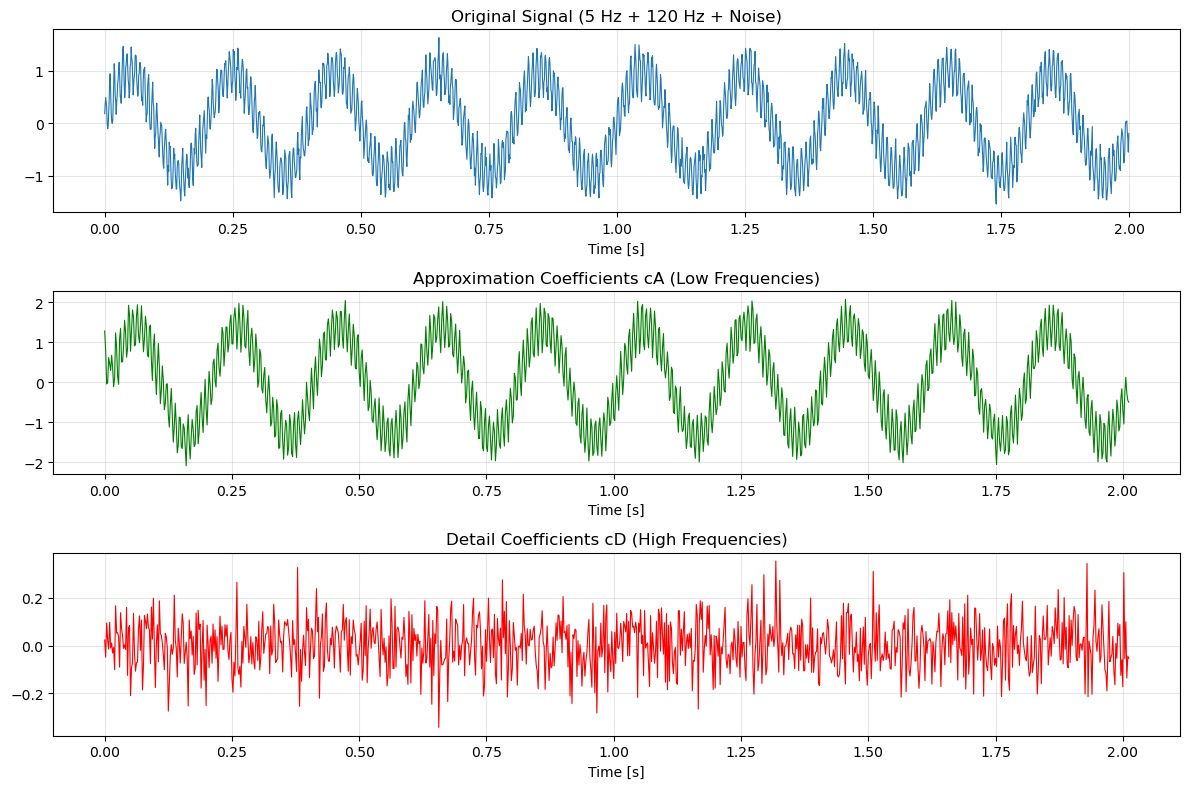

In [10]:
# Create a test signal with two distinct frequency bands
fs_dwt = 1024
t_dwt = np.arange(2048) / fs_dwt
signal_dwt = (np.sin(2 * np.pi * 5 * t_dwt) + 
              0.4 * np.sin(2 * np.pi * 120 * t_dwt) + 
              0.1 * np.random.randn(len(t_dwt)))

# Single-level DWT using Daubechies-8
cA, cD = pywt.dwt(signal_dwt, 'db8')

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(t_dwt, signal_dwt, linewidth=0.8)
axes[0].set_title('Original Signal (5 Hz + 120 Hz + Noise)')
axes[0].set_xlabel('Time [s]')
axes[0].grid(True, alpha=0.3)

# cA is downsampled by 2
t_cA = np.arange(len(cA)) / (fs_dwt / 2)
axes[1].plot(t_cA, cA, color='green', linewidth=0.8)
axes[1].set_title('Approximation Coefficients cA (Low Frequencies)')
axes[1].set_xlabel('Time [s]')
axes[1].grid(True, alpha=0.3)

t_cD = np.arange(len(cD)) / (fs_dwt / 2)
axes[2].plot(t_cD, cD, color='red', linewidth=0.8)
axes[2].set_title('Detail Coefficients cD (High Frequencies)')
axes[2].set_xlabel('Time [s]')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Multi-Level Decomposition & Reconstruction

We can apply DWT recursively to the approximation coefficients, creating a **wavelet decomposition tree**. Level $j$ produces:
- One approximation: cA$j$
- $j$ detail bands: cD$j$, cD$j-1$, ..., cD1

The original signal can be perfectly reconstructed from these coefficients using the Inverse DWT (IDWT), provided we use the same wavelet.


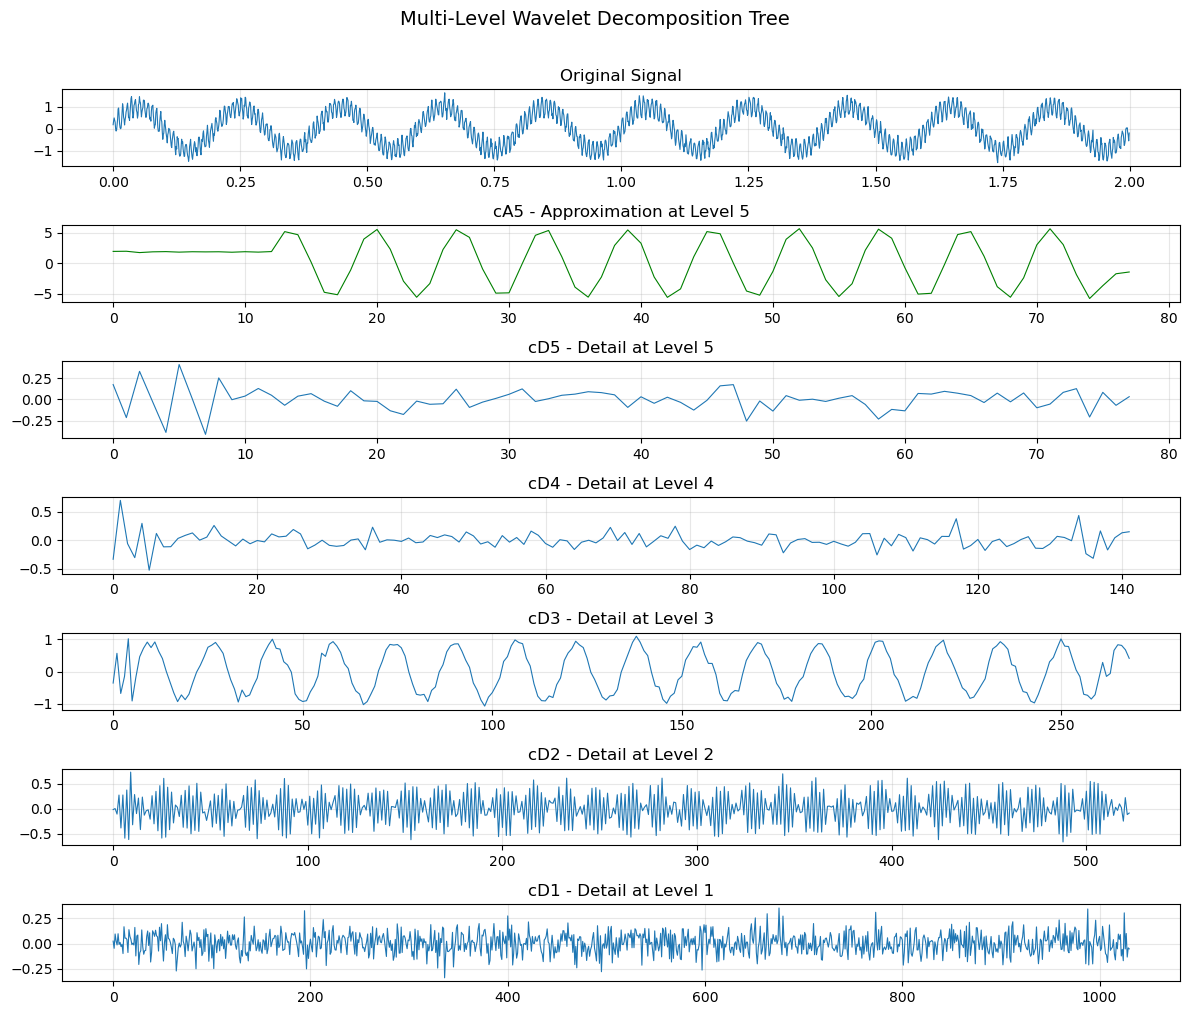

Reconstruction MSE: 1.12e-31


In [11]:
wavelet = 'db8'
level = 5
coeffs = pywt.wavedec(signal_dwt, wavelet, level=level)

fig, axes = plt.subplots(level + 2, 1, figsize=(12, 10))

axes[0].plot(t_dwt, signal_dwt, linewidth=0.8)
axes[0].set_title('Original Signal')
axes[0].grid(True, alpha=0.3)

# Approximation at highest level
axes[1].plot(coeffs[0], color='green', linewidth=0.8)
axes[1].set_title(f'cA{level} - Approximation at Level {level}')
axes[1].grid(True, alpha=0.3)

# Detail coefficients from coarse to fine
for i in range(1, len(coeffs)):
    ax = axes[i + 1]
    ax.plot(coeffs[i], linewidth=0.8)
    detail_level = level - i + 1
    ax.set_title(f'cD{detail_level} - Detail at Level {detail_level}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Multi-Level Wavelet Decomposition Tree', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Perfect reconstruction
reconstructed = pywt.waverec(coeffs, wavelet)
reconstructed = reconstructed[:len(signal_dwt)]  # trim padding
mse = np.mean((signal_dwt - reconstructed)**2)
print(f"Reconstruction MSE: {mse:.2e}")


## 5. Scale-to-Frequency Relationship

In wavelet analysis, **scale** is inversely proportional to frequency. For a given wavelet with center frequency $F_c$:

$$F_a = \frac{F_c}{a \cdot \Delta t}$$

Where $a$ is the scale and $\Delta t$ is the sampling period. Lower scales capture high frequencies and fine time details; higher scales capture low frequencies and coarse trends.

This is fundamentally different from Fourier, where frequency bins are uniformly spaced. Wavelets offer **constant-Q filtering**: the bandwidth is proportional to the center frequency.


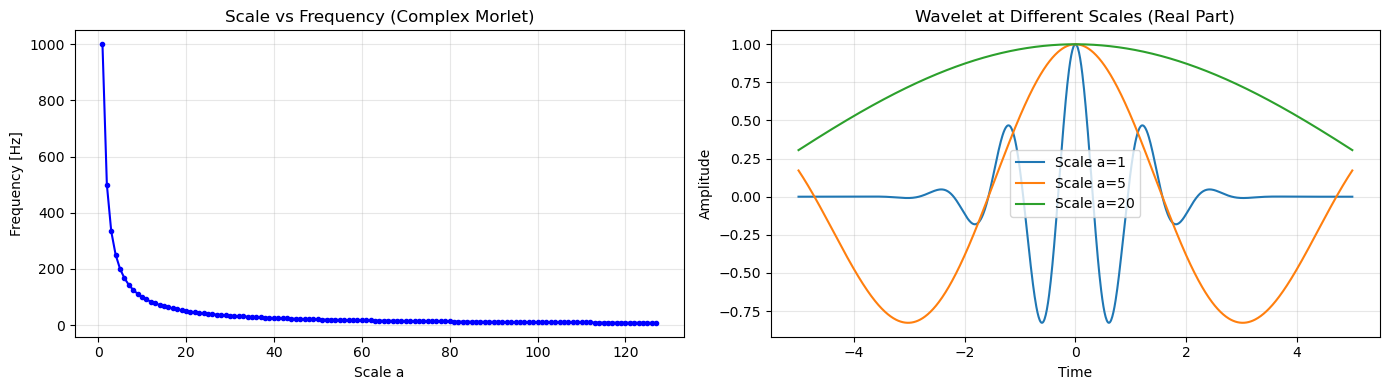

In [12]:
# Demonstrate scale-to-frequency mapping
scales = np.arange(1, 128)
wavelet_name = 'cmor1.5-1.0'
dt = 1 / 1000  # 1 kHz sampling

# PyWavelets scale2frequency
freqs = pywt.scale2frequency(wavelet_name, scales) / dt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(scales, freqs, 'b-o', markersize=3)
axes[0].set_title('Scale vs Frequency (Complex Morlet)')
axes[0].set_xlabel('Scale a')
axes[0].set_ylabel('Frequency [Hz]')
axes[0].grid(True, alpha=0.3)

# Visualize wavelets at different scales
t_wave = np.linspace(-5, 5, 1000)
for a in [1, 5, 20]:
    # Morlet wavelet at scale a
    psi = np.exp(1j * 5 * t_wave / a) * np.exp(-0.5 * (t_wave / a)**2)
    axes[1].plot(t_wave, np.real(psi), label=f'Scale a={a}')
axes[1].set_title('Wavelet at Different Scales (Real Part)')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Amplitude')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Wavelet Denoising via Thresholding

Because wavelets compact signal energy into a few large coefficients while spreading noise energy across many small coefficients, we can denoise by **thresholding** the detail coefficients.

Steps:
1. Decompose the noisy signal to a chosen level
2. Estimate noise standard deviation $\sigma$ from the finest detail coefficients
3. Apply a threshold (e.g., universal threshold: $\sigma \sqrt{2 \log N}$)
4. Reconstruct from modified coefficients

Modes: `soft` (shrinks toward zero) or `hard` (kills below threshold).


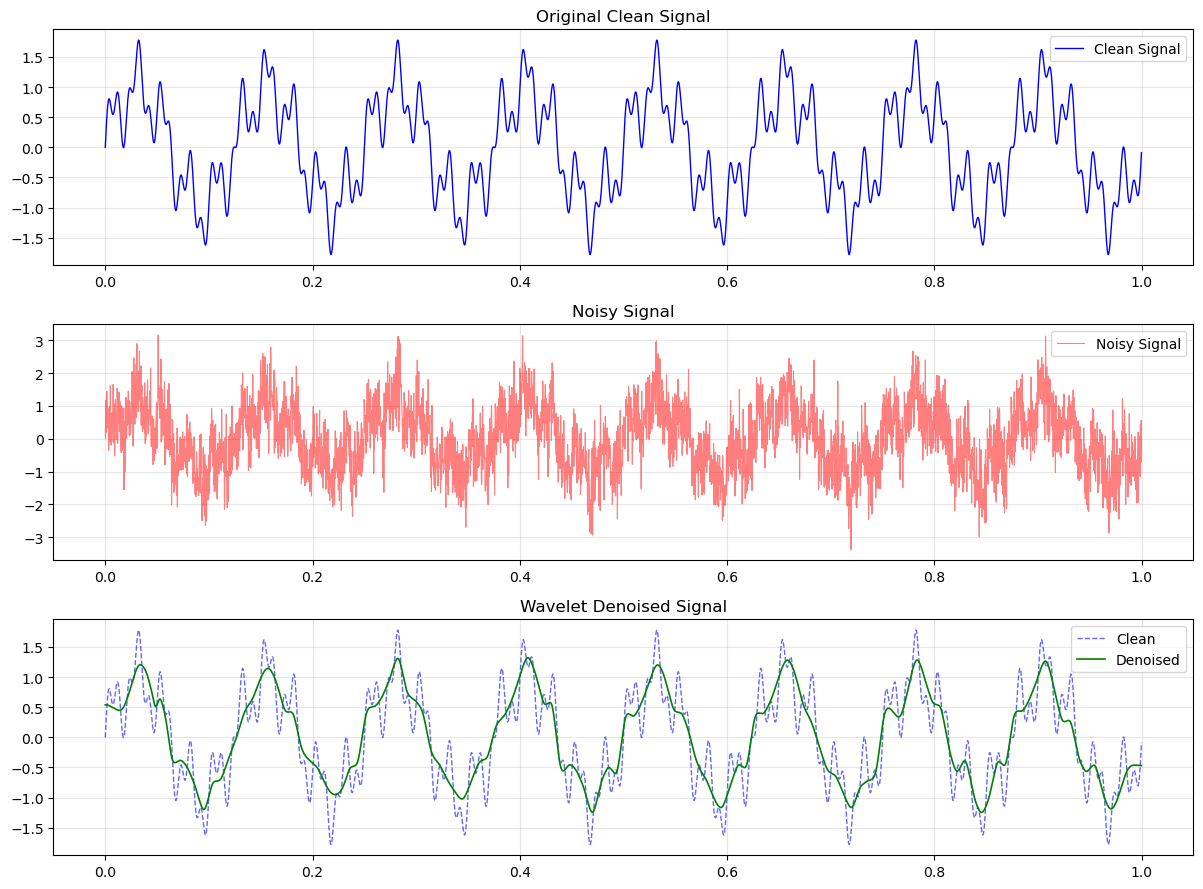

MSE noisy:    0.3579
MSE denoised: 0.1248


In [13]:
# Generate clean and noisy signals
np.random.seed(42)
t_den = np.linspace(0, 1, 4096, endpoint=False)
clean = (np.sin(2 * np.pi * 8 * t_den) + 
         0.5 * np.sin(2 * np.pi * 40 * t_den) + 
         0.3 * np.sin(2 * np.pi * 100 * t_den))
noisy = clean + 0.6 * np.random.randn(len(t_den))

# Wavelet denoising
wname = 'sym8'
wlevel = 6
coeffs = pywt.wavedec(noisy, wname, level=wlevel)

# Estimate noise level from finest detail coefficients
sigma = np.median(np.abs(coeffs[-1])) / 0.6745
uthresh = sigma * np.sqrt(2 * np.log(len(noisy)))

# Soft threshold detail coefficients only
coeffs_thresh = [coeffs[0]]  # keep approximation
for detail in coeffs[1:]:
    coeffs_thresh.append(pywt.threshold(detail, value=uthresh, mode='soft'))

denoised = pywt.waverec(coeffs_thresh, wname)[:len(t_den)]

fig, axes = plt.subplots(3, 1, figsize=(12, 9))

axes[0].plot(t_den, clean, 'b-', linewidth=1, label='Clean Signal')
axes[0].set_title('Original Clean Signal')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_den, noisy, 'r-', alpha=0.5, linewidth=0.8, label='Noisy Signal')
axes[1].set_title('Noisy Signal')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_den, clean, 'b--', alpha=0.6, linewidth=1, label='Clean')
axes[2].plot(t_den, denoised, 'g-', linewidth=1.2, label='Denoised')
axes[2].set_title('Wavelet Denoised Signal')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"MSE noisy:    {np.mean((clean - noisy)**2):.4f}")
print(f"MSE denoised: {np.mean((clean - denoised)**2):.4f}")


## 7. Fourier vs Wavelet: Time-Frequency Resolution Trade-off

The **Fourier Transform** uses a fixed window size, meaning time and frequency resolution are constant across all frequencies. The **STFT** inherits this limitation.

**Wavelets** use **variable windows**:
- High frequencies: short windows → good time resolution, poor frequency resolution
- Low frequencies: long windows → good frequency resolution, poor time resolution

This **multi-resolution analysis** is ideal for signals with transient features and non-stationary behavior.


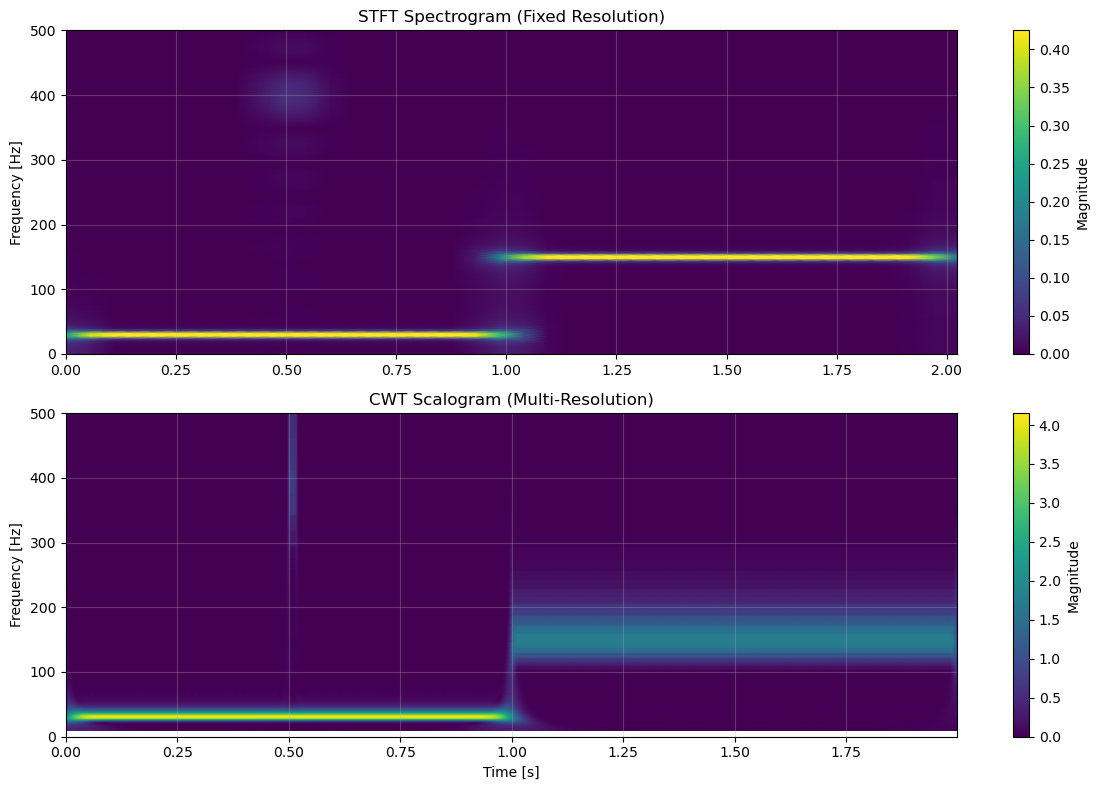

In [14]:
# Signal with frequency change and a brief transient
fs = 2048
t_comp = np.linspace(0, 2, 2 * fs, endpoint=False)
sig_comp = np.zeros_like(t_comp)
sig_comp[:fs] = np.sin(2 * np.pi * 30 * t_comp[:fs])
sig_comp[fs:] = np.sin(2 * np.pi * 150 * t_comp[fs:])

# Add a short 400 Hz click at t = 0.5s
click_start, click_end = int(0.5 * fs), int(0.52 * fs)
sig_comp[click_start:click_end] += 0.8 * np.sin(2 * np.pi * 400 * t_comp[click_start:click_end])

# STFT
f_stft, t_stft, Zxx = stft(sig_comp, fs=fs, nperseg=512, noverlap=400)

# CWT
scales = np.arange(1, 200)
coef_cwt, freqs_cwt = pywt.cwt(sig_comp, scales, 'cmor1.5-1.0', sampling_period=1/fs)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# STFT Spectrogram
im1 = axes[0].pcolormesh(t_stft, f_stft, np.abs(Zxx), shading='gouraud', cmap='viridis')
axes[0].set_title('STFT Spectrogram (Fixed Resolution)')
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_ylim(0, 500)
fig.colorbar(im1, ax=axes[0], label='Magnitude')

# CWT Scalogram
im2 = axes[1].pcolormesh(t_comp, freqs_cwt, np.abs(coef_cwt), shading='gouraud', cmap='viridis')
axes[1].set_title('CWT Scalogram (Multi-Resolution)')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_ylim(0, 500)
fig.colorbar(im2, ax=axes[1], label='Magnitude')

plt.tight_layout()
plt.show()


## 8. Wavelet Packet Decomposition

Wavelet packets extend DWT by also decomposing the **detail** branches, not just the approximation branches. This produces a full binary tree of subspaces, offering finer frequency partitioning.

At level $j$, there are $2^j$ packets, each covering a specific frequency band. This is useful for applications like feature extraction, compression, and specialized denoising.


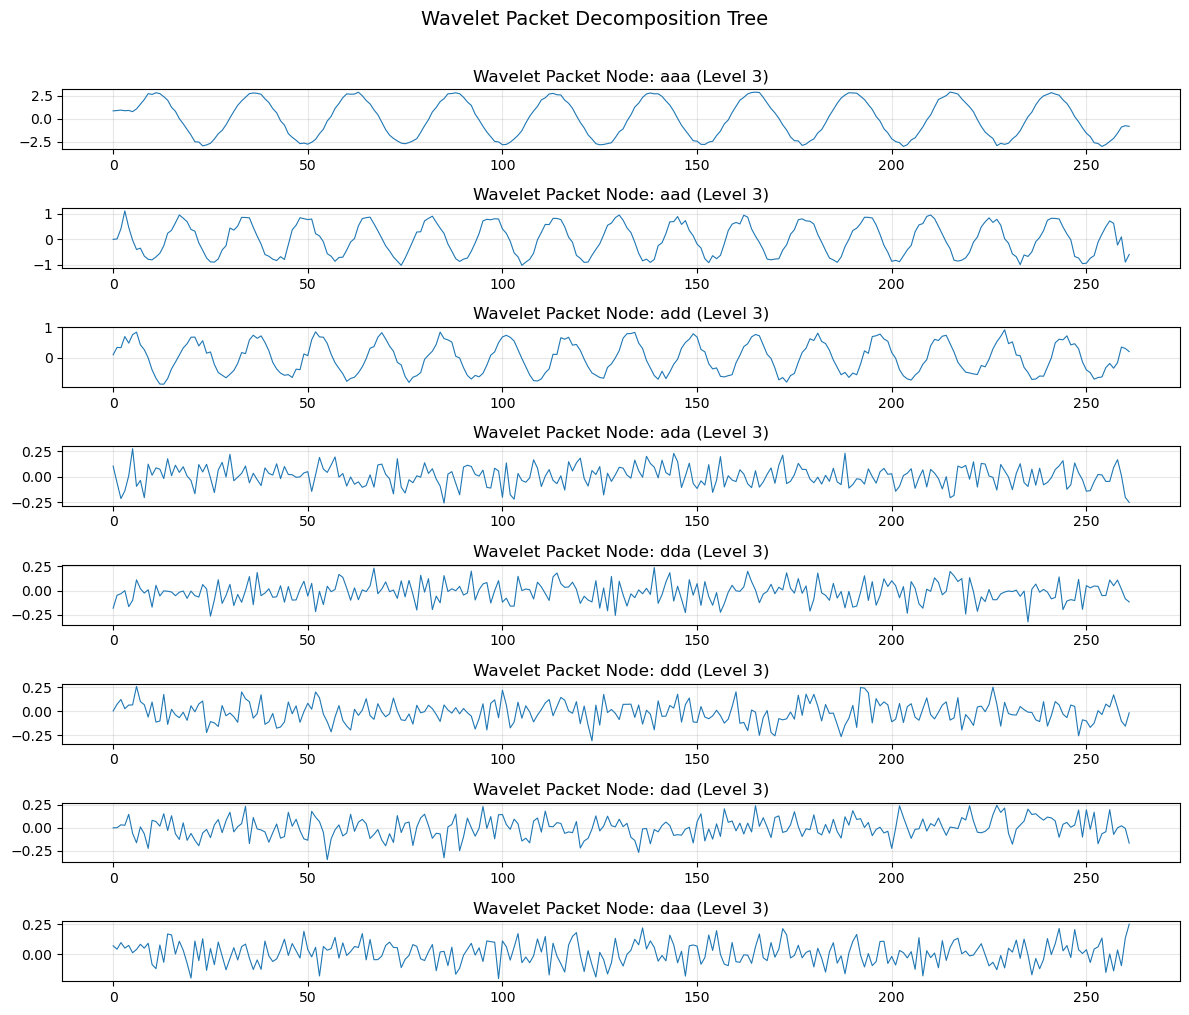

Wavelet Packet tree nodes at level 3
['aaa', 'aad', 'add', 'ada', 'dda', 'ddd', 'dad', 'daa']


In [15]:
# Wavelet Packet decomposition
wp = pywt.WaveletPacket(data=signal_dwt, wavelet='db4', mode='symmetric')
wp_level = 3
nodes = wp.get_level(wp_level, order='freq')

fig, axes = plt.subplots(len(nodes), 1, figsize=(12, 10))

for i, node in enumerate(nodes):
    axes[i].plot(node.data, linewidth=0.8)
    axes[i].set_title(f'Wavelet Packet Node: {node.path} (Level {wp_level})')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Wavelet Packet Decomposition Tree', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Show the binary tree structure
print("Wavelet Packet tree nodes at level", wp_level)
print([node.path for node in nodes])


## Summary

| Feature | Fourier / STFT | Wavelet Transform |
|---------|---------------|-------------------|
| **Basis** | Sine/Cosine (infinite) | Localized wavelets |
| **Resolution** | Fixed (STFT) | Variable (multi-resolution) |
| **Best for** | Stationary, periodic signals | Transients, non-stationary signals |
| **Redundancy** | None (FFT) / Fixed (STFT) | CWT: redundant; DWT: minimal |
| **Speed** | $O(N \log N)$ | DWT: $O(N)$; CWT: slower |
| **Denoising** | Frequency masking | Coefficient thresholding |

Wavelets provide the time-frequency localization that Fourier methods lack, making them indispensable for analyzing real-world signals with abrupt changes, trends, and scale-dependent features.
